# Decision Trees - Practice 1

Classification trees with Titanic data file

In [40]:
from IPython.display import display, HTML

# Larger figures
#display(HTML("<style>.container { width:100% !important; }</style>")) # Increase cell width
#display(HTML("<style>.rendered_html { font-size: 16px; }</style>")) # Increase font size

import pandas as pd

#pd.options.display.float_format = '{:.3f}'.format
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
import numpy as np
import seaborn as sns

from sklearn.metrics import auc, roc_curve, f1_score, accuracy_score, precision_recall_curve, confusion_matrix, classification_report
from sklearn.metrics import recall_score, precision_score
from sklearn import metrics
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import cross_val_score

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Loading

Variable description:

- **survived:	Survival (target variable) - 0 = No, 1 = Yes**
- pclass:	Ticket class - 1 = 1st, 2 = 2nd, 3 = 3rd
- sex:	    Sex 0 male, 1 female
- age:	    Age in years
- sibsp:	# of siblings / spouses aboard the Titanic
- parch:	# of parents / children aboard the Titanic
- ticket:	Ticket number
- fare:	    Passenger fare
- cabin:	Cabin number
- embarked:	Port of Embarkation - C = Cherbourg, Q = Queenstown, S = Southampton


Let's load the dataset and review null values

In [42]:
#import openpyxl # not really needed

# Red data
filename = '/content/drive/MyDrive/IE/Courses/ML_II/Decision trees and RF/Decision trees/titanic.xlsx'
df = pd.read_excel(filename, 1) #it has two sheets, we load the 2nd one
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   int64  
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   float64
dtypes: float64(3), int64(5), object(2)
memory usage: 102.4+ KB


In [43]:
print ("Records and variables: ", df.shape)
print ("Column names: ", df.columns.to_list())

Records and variables:  (1309, 10)
Column names:  ['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


In [44]:
df.head()

,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,1,29.0000,0,0,24160,211.3375,B5,2.0
1,1,1,0,0.9167,1,2,113781,151.5500,C22 C26,2.0
2,1,0,1,2.0000,1,2,113781,151.5500,C22 C26,2.0
3,1,0,0,30.0000,1,2,113781,151.5500,C22 C26,2.0
4,1,0,1,25.0000,1,2,113781,151.5500,C22 C26,2.0


Show % of records from each of the survived class (Class 1 = Survived)

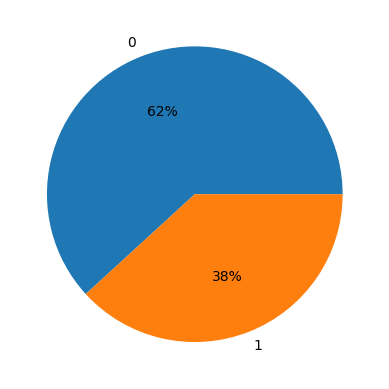

In [45]:
target = "survived"
unique, counts = np.unique(df[target], return_counts=True)
plt.pie(counts, labels=unique, autopct='%.0f%%');

In [46]:
from collections import Counter

def class_perc(data):
    lendata = len(data)
    classes = Counter(data)

    for sclass, freq in classes.items():
        perc = (freq / lendata) * 100
        print(f"Class '{sclass}': {perc:.2f}%")

class_perc(df['survived'])

Class '1': 38.20%
Class '0': 61.80%


In [47]:
df.isnull().sum() #null values

,0
pclass,0
survived,0
sex,0
age,263
sibsp,0
parch,0
ticket,0
fare,1
cabin,1014
embarked,2


4 variables with null values, mostly cabin and age. <BR>
We can discard cabin since it appears to be meaningless (and also ticket). <BR>
We will need to delete records with missing values, since scikit uses CART by default and this algorithm stops if it finds any

In [48]:
df['cabin'].unique()

array(['B5', 'C22 C26', 'E12', 'D7', 'A36', 'C101', nan, 'C62 C64', 'B35',
       'A23', 'B58 B60', 'D15', 'C6', 'D35', 'C148', 'C97', 'B49', 'C99',
       'C52', 'T', 'A31', 'C7', 'C103', 'D22', 'E33', 'A21', 'B10', 'B4',
       'E40', 'B38', 'E24', 'B51 B53 B55', 'B96 B98', 'C46', 'E31', 'E8',
       'B61', 'B77', 'A9', 'C89', 'A14', 'E58', 'E49', 'E52', 'E45',
       'B22', 'B26', 'C85', 'E17', 'B71', 'B20', 'A34', 'C86', 'A16',
       'A20', 'A18', 'C54', 'C45', 'D20', 'A29', 'C95', 'E25', 'C111',
       'C23 C25 C27', 'E36', 'D34', 'D40', 'B39', 'B41', 'B102', 'C123',
       'E63', 'C130', 'B86', 'C92', 'A5', 'C51', 'B42', 'C91', 'C125',
       'D10 D12', 'B82 B84', 'E50', 'D33', 'C83', 'B94', 'D49', 'D45',
       'B69', 'B11', 'E46', 'C39', 'B18', 'D11', 'C93', 'B28', 'C49',
       'B52 B54 B56', 'E60', 'C132', 'B37', 'D21', 'D19', 'C124', 'D17',
       'B101', 'D28', 'D6', 'D9', 'B80', 'C106', 'B79', 'C47', 'D30',
       'C90', 'E38', 'C78', 'C30', 'C118', 'D36', 'D48', 'D47', '

In [49]:
# droppping cabin, ticket & embarked (the later is nominal)
df.drop(labels=['cabin', 'ticket'], axis=1, inplace=True)

In [50]:
df.columns

Index(['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='object')

In [51]:
df=df.dropna(subset=['age', 'fare'])
df.describe()

,pclass,survived,sex,age,sibsp,parch,fare,embarked
count,1045.000000,1045.000000,1045.000000,1045.000000,1045.000000,1045.000000,1045.000000,1043.000000
mean,2.206699,0.408612,0.371292,29.851834,0.503349,0.421053,36.686080,1.545542
std,0.841542,0.491813,0.483382,14.389201,0.912471,0.840052,55.732533,0.809366
min,1.000000,0.000000,0.000000,0.166700,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,8.050000,1.000000
50%,2.000000,0.000000,0.000000,28.000000,0.000000,0.000000,15.750000,2.000000
75%,3.000000,1.000000,1.000000,39.000000,1.000000,1.000000,35.500000,2.000000
max,3.000000,1.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000


We are going to split it into training and test (with same class distribution of survived variable in each set)

In [52]:
from sklearn.model_selection import train_test_split

X = df.loc[:, df.columns != 'survived'] # removal of target variable from explanatories
y = df['survived']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y) # Changed percentage=0.5 to test_size=0.5

In [53]:
print("Training data set: ", X_train.shape)
print("Testing data set: ", X_test.shape)

class_perc(Y_train.to_frame(name='survived')["survived"])
class_perc(Y_test.to_frame(name='survived')["survived"])

Training data set:  (522, 7)
Testing data set:  (523, 7)
Class '1': 40.80%
Class '0': 59.20%
Class '0': 59.08%
Class '1': 40.92%


## Classification Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier

my_tree = DecisionTreeClassifier(criterion="entropy", random_state=42)
my_tree.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

Let's take a look to the performance of the classifier (by using initially accuracy, recall,  precision and f1 score)

In [55]:
measure = "accuracy"
pred_train = my_tree.predict(X_train)
# this is an overly complicated method to get different accuracies easily for this demo.
# you could easily specify  accuracy_score(Y_train, pred_train)
# or f1_score(Y_train, pred_train), recall_score(Y_train, pred_train)...
print(measure + " of training set = {0:.2%}".format(globals()[measure + "_score"](Y_train, pred_train)))

pred_test = my_tree.predict(X_test)
print(measure + " of testing set = {0:.2%}".format(globals()[measure + "_score"](Y_test, pred_test)))

accuracy of training set = 98.66%
accuracy of testing set = 76.29%


What does the result mean?


Now we will take a look to the tree itself. <BR>This is a bit complex since sklearn does not provide a way to visualize the models. To that end, we will need to make use of an external library: `pydotplus`.

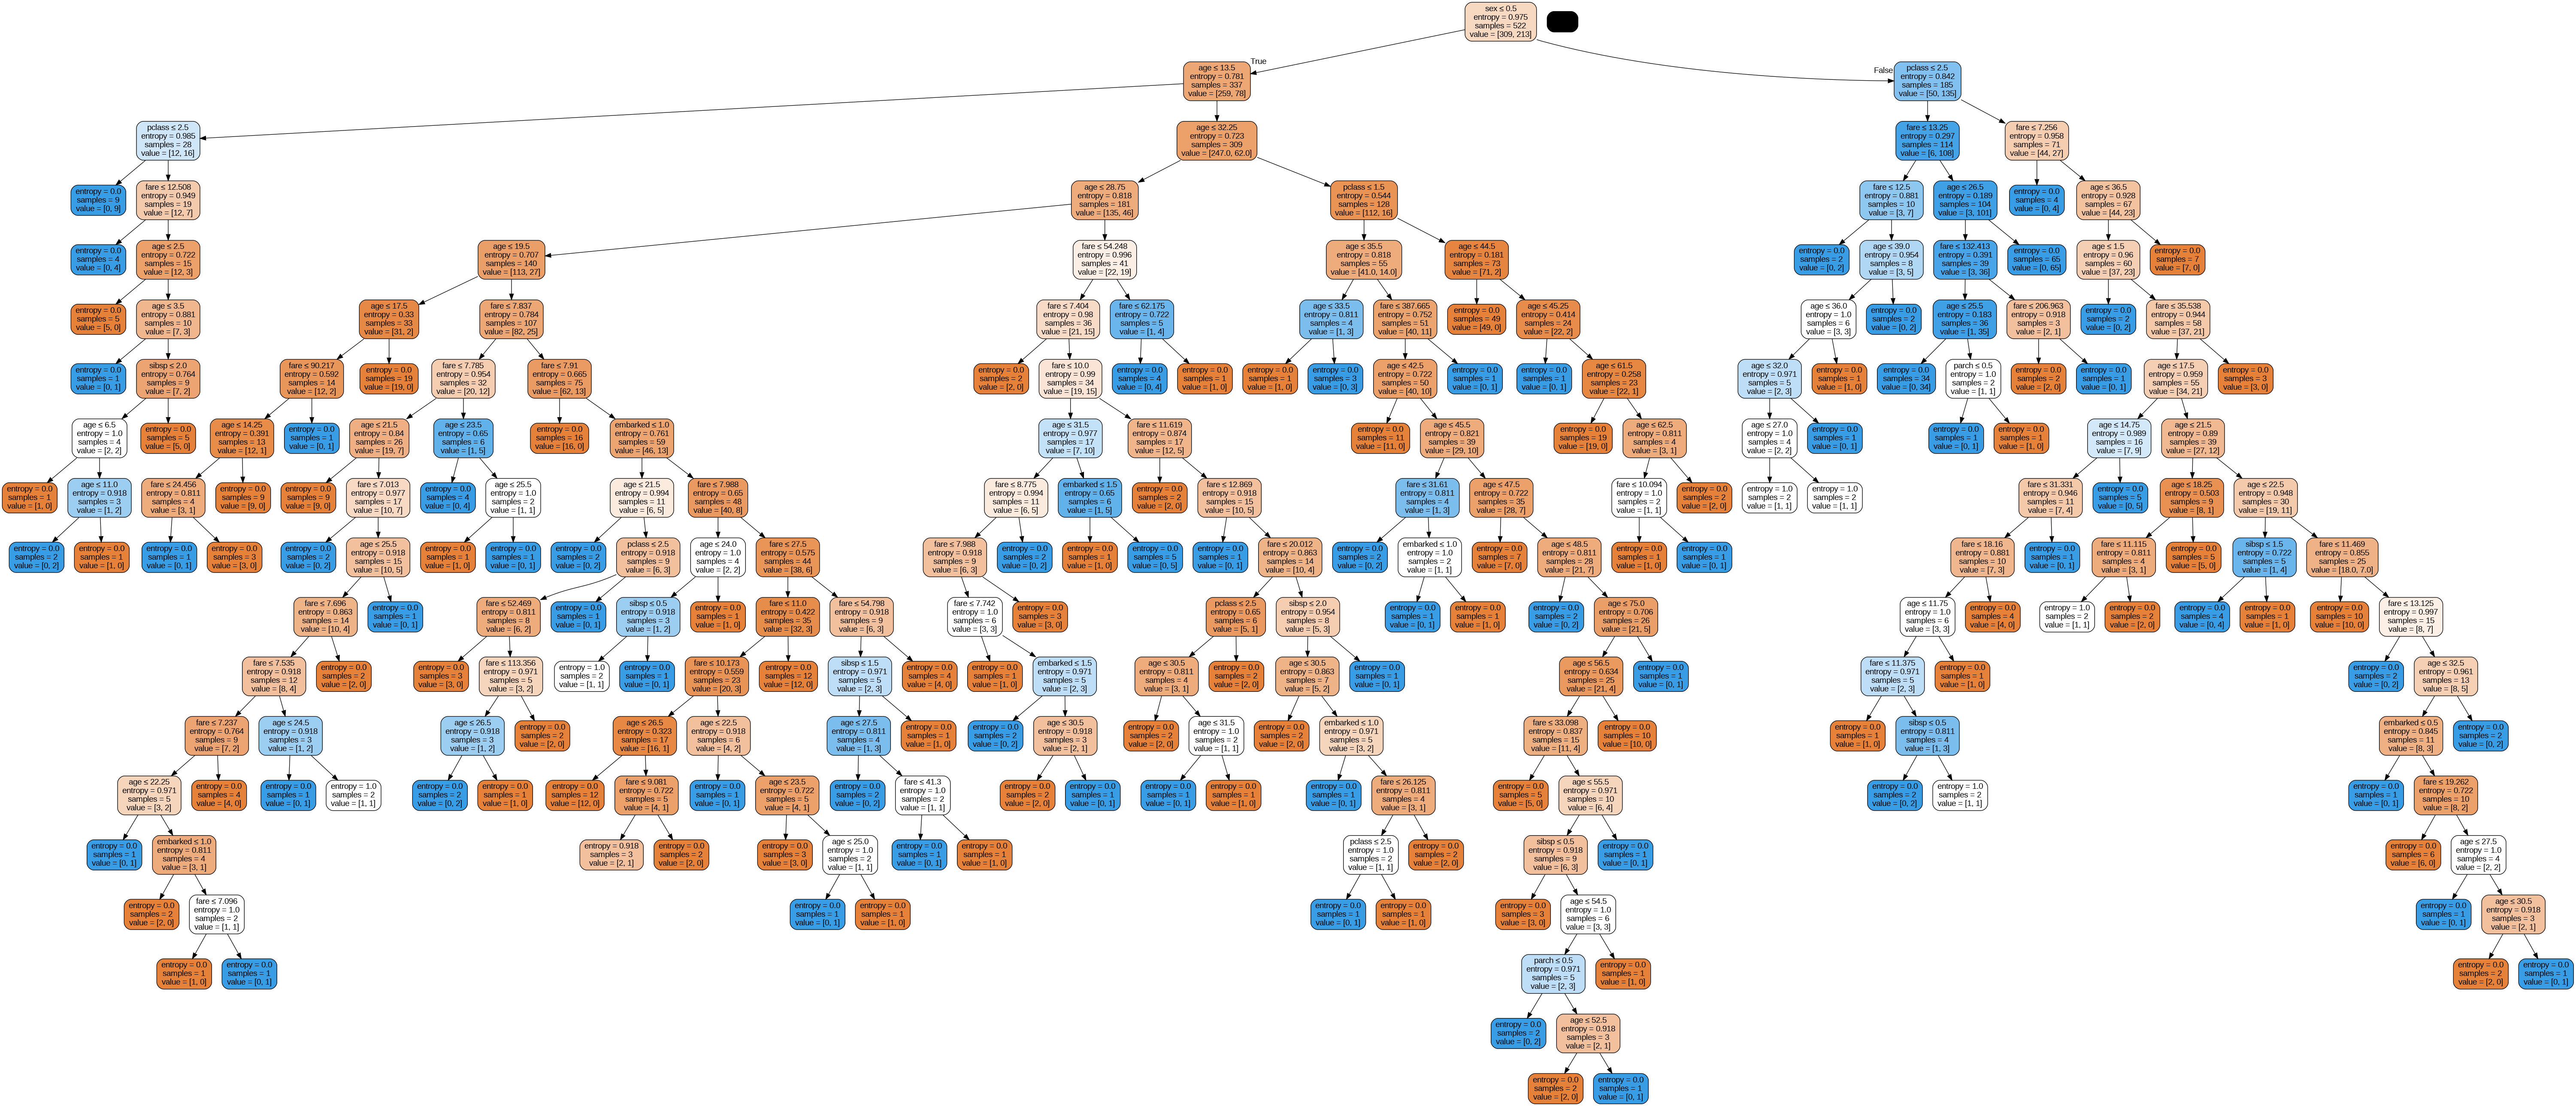

In [57]:
#!pip install pydotplus
#!pip install graphviz
#!pip install io

# you may need to install also this library directly from https://graphviz.gitlab.io/_pages/Download/Download_windows.html
# and then uncomment following two lines
#import os
#os.environ["PATH"] += os.pathsep + 'C:\Program Files (x86)\Graphviz2.38/bin/'(installation folder)

from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

def plot_tree(tree, feature_names):
    dot_data = StringIO()
    export_graphviz(tree, out_file=dot_data, feature_names=feature_names,
                    filled=True, rounded=True,special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    graph.write_png("titanic_train.png")
    return Image(graph.create_png())


plot_tree(my_tree, X_train.columns)

In [58]:
# We can explore each node, for instance this is root node
root_node=my_tree.tree_
node=2
print("Samples: ", root_node.n_node_samples[node])
print("Proportions per class: ",root_node.value[node])
print("Samples per class: ", root_node.value[node]*root_node.n_node_samples[node])
print("Impurity: {0:.2%}".format(root_node.impurity[node]))

Samples:  28
Proportions per class:  [[0.42857143 0.57142857]]
Samples per class:  [[12. 16.]]
Impurity: 98.52%


In [59]:
# How many nodes and leaves?
print("Number of nodes: ", my_tree.tree_.node_count)
print("Number of leaves: ", my_tree.get_n_leaves())
print("Depth: ", my_tree.get_depth())

Number of nodes:  265
Number of leaves:  133
Depth:  18


We will plot the feature importance

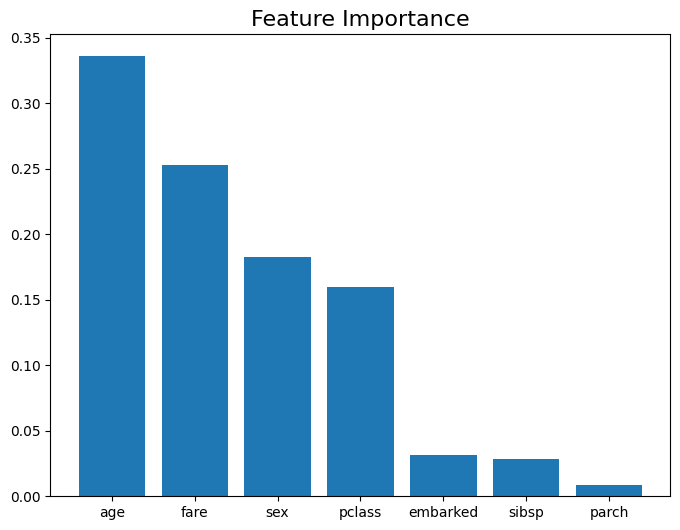

In [60]:
plt.figure(figsize=(8,6))
importances = my_tree.feature_importances_
indices = np.argsort(importances)[::-1]
plt.bar(X_train.columns[indices], importances[indices]) #average reduction in impurity resulting from splitting at each node of the tree using that feature
plt.title('Feature Importance', fontsize=16);

## Pruning the tree

The tree, as it is presented, will surely overfit.

Therefore, we will have to prune it to improve performance in the test set.

There are different Pruning Parameters:

 - max_leaf_nodes: Reduce the number of leaf nodes
 - min_samples_leaf: Restrict the size of sample leaf. Minimum sample size in terminal nodes can be fixed to a number or a % of total
 - max_depth: Reduce the depth of the tree to build a generalized tree. Set the depth of the tree to different values depending after verification on test data
 - etc..

Let's focus for now on the depth of the tree. We will test different depth thresholds via CV (k-fold) by using the `GridSearchCV` provided by sklearn.

In [61]:
from sklearn.model_selection import GridSearchCV

# this takes some time since it has to build a model for every combination from the param_grid dict
param_grid = {
    'max_depth': range(2,10),
    'min_samples_leaf': [5, 10, 15]
}

tree_pruned_cv = GridSearchCV(my_tree,
                   param_grid,
                   scoring=measure, # we change the scoring criteria here
                   cv=5 , n_jobs=-1, verbose=1)

tree_pruned_cv.fit(X_train,Y_train);

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [62]:
print("Best parameters set found on development set:")
print()
print(tree_pruned_cv.best_params_)
print()
print("Grid scores on development set:")
print()
means = tree_pruned_cv.cv_results_['mean_test_score']
stds = tree_pruned_cv.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, tree_pruned_cv.cv_results_['params']):
    print(measure, "= %0.3f (+/%0.03f) for %r" % (mean, std * 2, params))

Best parameters set found on development set:

{'max_depth': 3, 'min_samples_leaf': 5}

Grid scores on development set:

accuracy = 0.786 (+/0.043) for {'max_depth': 2, 'min_samples_leaf': 5}
accuracy = 0.786 (+/0.043) for {'max_depth': 2, 'min_samples_leaf': 10}
accuracy = 0.786 (+/0.043) for {'max_depth': 2, 'min_samples_leaf': 15}
accuracy = 0.791 (+/0.064) for {'max_depth': 3, 'min_samples_leaf': 5}
accuracy = 0.782 (+/0.046) for {'max_depth': 3, 'min_samples_leaf': 10}
accuracy = 0.776 (+/0.055) for {'max_depth': 3, 'min_samples_leaf': 15}
accuracy = 0.784 (+/0.053) for {'max_depth': 4, 'min_samples_leaf': 5}
accuracy = 0.749 (+/0.095) for {'max_depth': 4, 'min_samples_leaf': 10}
accuracy = 0.766 (+/0.046) for {'max_depth': 4, 'min_samples_leaf': 15}
accuracy = 0.759 (+/0.101) for {'max_depth': 5, 'min_samples_leaf': 5}
accuracy = 0.761 (+/0.087) for {'max_depth': 5, 'min_samples_leaf': 10}
accuracy = 0.757 (+/0.053) for {'max_depth': 5, 'min_samples_leaf': 15}
accuracy = 0.763 (+

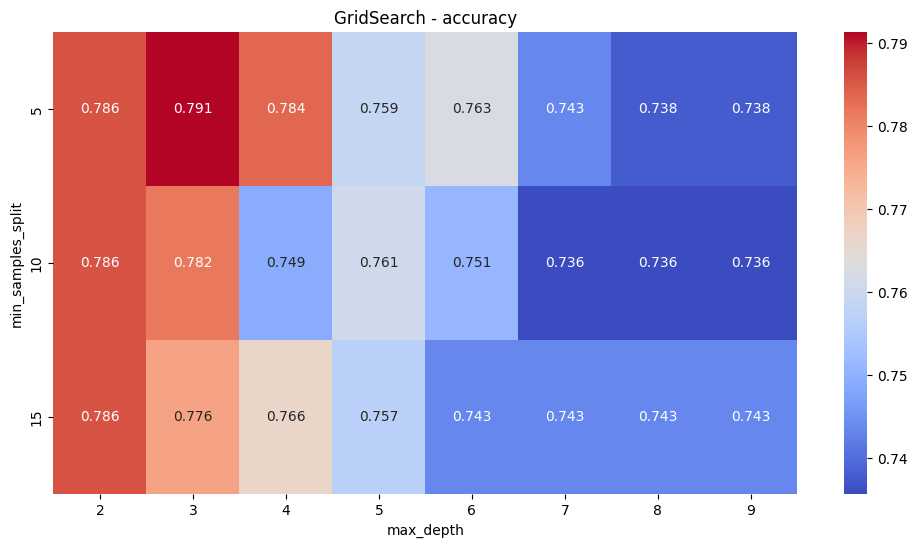

In [63]:
results = pd.DataFrame(tree_pruned_cv.cv_results_)

results = results[['param_max_depth', 'param_min_samples_leaf', 'mean_test_score']]
results.columns = ['max_depth', 'min_samples_leaf', measure]

pivot_table = results.pivot(index='min_samples_leaf', columns='max_depth', values=measure)

# Show the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("GridSearch - " + measure)
plt.xlabel("max_depth")
plt.ylabel("min_samples_split")
plt.show()

### Test data set

Let's now calculate our metric for test data set using the best parameters found

In [64]:
tree_pruned = DecisionTreeClassifier(random_state=42,
        max_depth=tree_pruned_cv.best_params_["max_depth"],
        min_samples_leaf=tree_pruned_cv.best_params_["min_samples_leaf"],
        criterion="entropy")

tree=tree_pruned.fit(X_train, Y_train)
predictions_test = tree_pruned.predict(X_test) # obtains predictions with a threshold=50%
print("train " + measure + "= ", "{0:.2%}".format(globals()[measure + "_score"](Y_train, pred_train)))
print("test " + measure + "= ",  "{0:.2%}".format(globals()[measure + "_score"](Y_test, predictions_test)))
print("test " + measure + " = ", "{0:.2%}".format(globals()[measure + "_score"](Y_test, predictions_test)))
print("test " + measure + " = ", "{0:.2%}".format(globals()[measure + "_score"](Y_test, predictions_test)))

train accuracy=  98.66%
test accuracy=  81.07%
test accuracy =  81.07%
test accuracy =  81.07%


We can see if the most important features are still the same in the test dataset

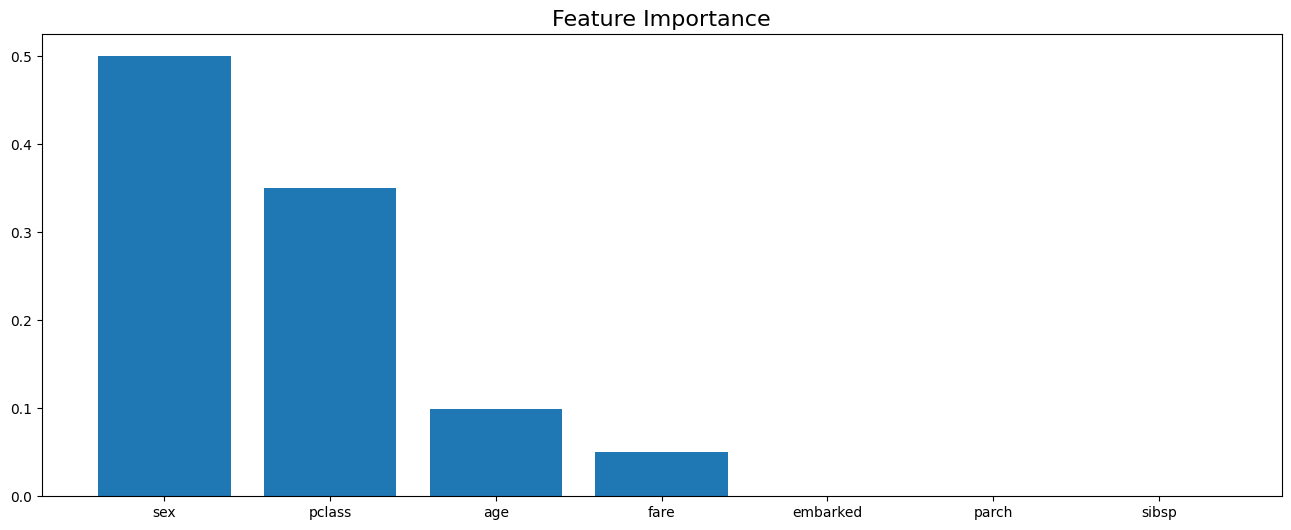

In [65]:
plt.figure(figsize=(16,6))
importances = tree_pruned.feature_importances_
indices = np.argsort(importances)[::-1]
plt.bar(X_train.columns[indices], importances[indices]) #average reduction in impurity resulting from splitting at each node of the tree using that feature
plt.title('Feature Importance', fontsize=16);

Now, we represent the different values for the metrics obtained using different thresholds of probabilities

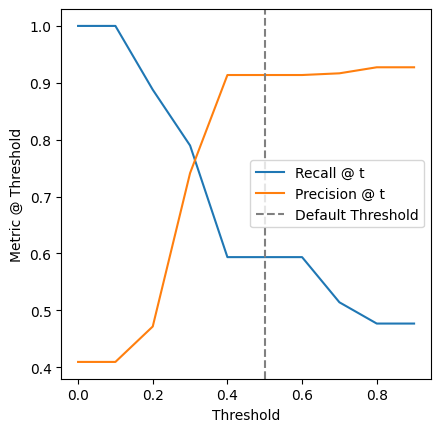

In [66]:
prob_pred = tree_pruned.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.0, 1.0, step=0.1)
# convert the predicted probabilities to binary
recall_scores = [metrics.recall_score(Y_test, prob_pred > t) for t in thresholds]
precis_scores = [metrics.precision_score(Y_test, prob_pred > t) for t in thresholds]

fig, ax = plt.subplots(1, 1)
ax.plot(thresholds, recall_scores, label="Recall @ t")
ax.plot(thresholds, precis_scores, label="Precision @ t")
ax.axvline(0.5, c="gray", linestyle="--", label="Default Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Metric @ Threshold")
ax.set_box_aspect(1)
ax.legend()
plt.show()

This can help us to change probability thresholds to balance precission and recall.

### Visualization of pruned tree

In [67]:
# How many nodes and leaves?
print("Number of nodes: ", tree_pruned.tree_.node_count)
print("Number of leaves: ", tree_pruned.get_n_leaves())
print("Depth: ", tree_pruned.get_depth())

Number of nodes:  15
Number of leaves:  8
Depth:  3


And we can represent the set of rules

In [68]:
from sklearn import tree

text_representation = tree.export_text(tree_pruned, feature_names=list(X_test.columns))
print(text_representation)

# optionally, we can export them to a text file
with open("tree_pruned.log", "w") as fout:
    fout.write(text_representation)

|--- sex <= 0.50
|   |--- age <= 13.50
|   |   |--- pclass <= 2.50
|   |   |   |--- class: 1
|   |   |--- pclass >  2.50
|   |   |   |--- class: 0
|   |--- age >  13.50
|   |   |--- age <= 32.25
|   |   |   |--- class: 0
|   |   |--- age >  32.25
|   |   |   |--- class: 0
|--- sex >  0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 13.25
|   |   |   |--- class: 1
|   |   |--- fare >  13.25
|   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 7.74
|   |   |   |--- class: 1
|   |   |--- fare >  7.74
|   |   |   |--- class: 0



Now, we can visualize the pruned tree

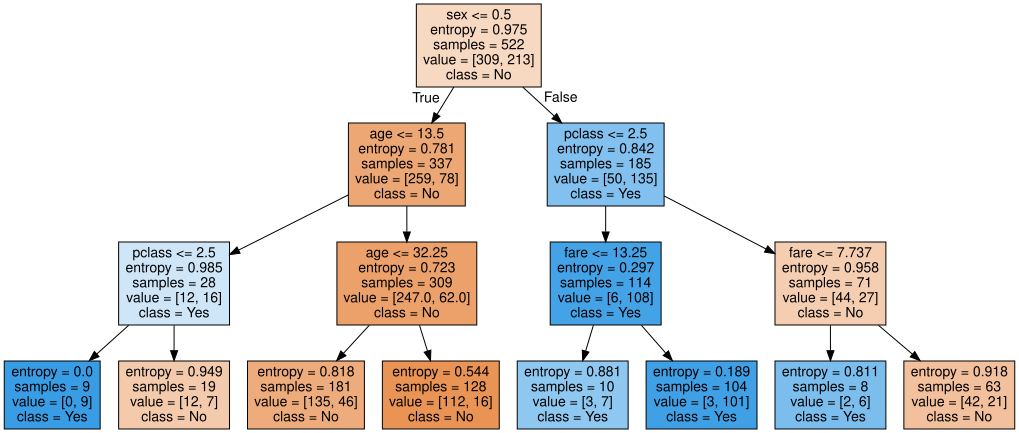

In [69]:
import graphviz
# DOT data
dot_data = tree.export_graphviz(tree_pruned, out_file=None,
                                class_names=["No","Yes"],
                                feature_names=X_train.columns,
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

In [70]:
# Save it into a high resolution image
graph.render("tree_pruned")

'tree_pruned.png'

and with the following code we can obtain a dataframe with all terminal nodes ordered by impurity ascending (the better nodes first)

In [71]:
t = tree_pruned.tree_

pred_class = np.argmax(t.value.squeeze(axis=1), axis=1)
pred_label = tree_pruned.classes_[pred_class]
counts = t.value.squeeze(axis=1)
percentages = counts / counts.sum(axis=1, keepdims=True) * 100
percentages = np.round(percentages, 2)

df = (
    pd.DataFrame({
        "node_id": np.arange(t.node_count),
        "impurity": t.impurity,
        "n_node_samples": t.n_node_samples,
        "feature_idx": t.feature,
        "threshold": t.threshold,
        "is_leaf": t.children_left == -1,
        "pred_class_label": pred_label,
        "class_counts": list(percentages)
    })
    .reset_index(drop=True)
)

df.query("feature_idx ==-2").sort_values(
    by=["impurity", "n_node_samples"],
    ascending=[True, False]
).drop(columns=["feature_idx", "threshold" ,"is_leaf"])

,node_id,impurity,n_node_samples,pred_class_label,class_counts
3,3,0.000000,9,1,"[0.0, 100.0]"
11,11,0.188572,104,1,"[2.88, 97.12]"
7,7,0.543564,128,0,"[87.5, 12.5]"
13,13,0.811278,8,1,"[25.0, 75.0]"
6,6,0.817780,181,0,"[74.59, 25.41]"
10,10,0.881291,10,1,"[30.0, 70.0]"
14,14,0.918296,63,0,"[66.67, 33.33]"
4,4,0.949452,19,0,"[63.16, 36.84]"


and here we can visuallize just one node (the top one for example), or a very impure one.

In [72]:
node = 3
print("Samples: ", t.n_node_samples[node])
print("Proportions per class: ",t.value[node])
print("Samples per class: ", t.value[node]*t.n_node_samples[node])
print("Impurity: {0:.2%}".format(t.impurity[node]))

Samples:  9
Proportions per class:  [[0. 1.]]
Samples per class:  [[0. 9.]]
Impurity: 0.00%


## Model performance

Finally, let's analyze model performance (on test data set) with a probability threshold that balances precision and recall. (See ROC later as well)

Optimal Threshold: 0.33


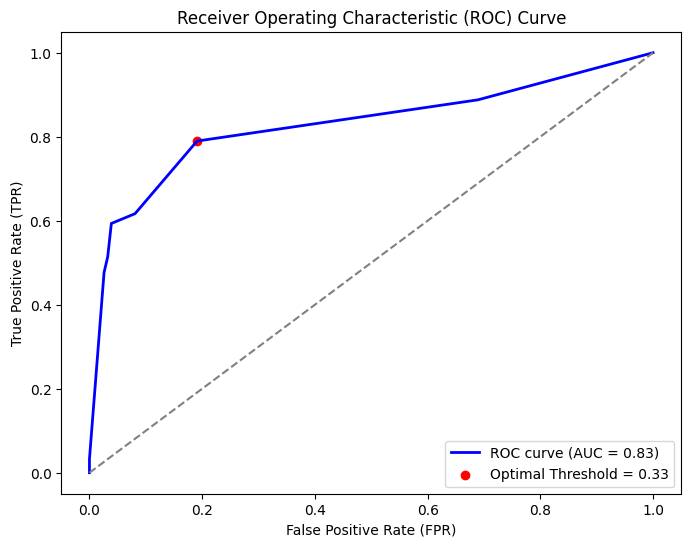

In [73]:
fpr, tpr, thresholds = roc_curve(Y_test, prob_pred)
roc_auc = auc(fpr, tpr)
optimal_idx = np.argmax(tpr - fpr)  # Best trade-off between TPR and FPR
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold:.2f}")

# ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classification

# Highlight optimal threshold
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', marker='o',
            label=f'Optimal Threshold = {optimal_threshold:.2f}')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

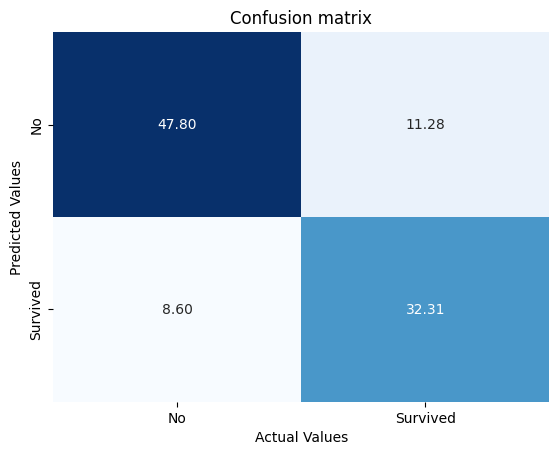

In [74]:
cutoff = 0.33

prob_pred = tree_pruned.predict_proba(X_test)[:, 1]
predictions_test = (prob_pred >= cutoff).astype(int)

test_conf_matrix = confusion_matrix(Y_test, predictions_test)
test_conf_matrix_percentage = test_conf_matrix.astype('float') / test_conf_matrix.sum() * 100
test_conf_matrix_percentage = np.round(test_conf_matrix_percentage, 2)
labels = ['No', 'Survived']

fig, ax = plt.subplots()
label_names = ['TN','FN','FP','TP']
label_counts = ['{0:0.0f}'.format(value) for value in test_conf_matrix_percentage.flatten()]

# Draw heatmap using confusion matrix
sns.heatmap(test_conf_matrix_percentage, annot=True, fmt='.2f', cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False)

ax.set_title('Confusion matrix')
ax.set_xlabel('Actual Values')
ax.set_ylabel('Predicted Values');

Lets have a look at the probabilities of survival according to specific traits. The predicted probabilities are an array with the probability of each observation of belonging to class 0 or 1.

In [75]:
tree_pruned.predict_proba(X_test)

array([[0.875     , 0.125     ],
       [0.        , 1.        ],
       [0.74585635, 0.25414365],
       ...,
       [0.02884615, 0.97115385],
       [0.74585635, 0.25414365],
       [0.02884615, 0.97115385]])

We can have a look at one group

In [76]:
tree_pruned.predict_proba(X_test[X_test['sex'] == 1])

array([[0.66666667, 0.33333333],
       [0.66666667, 0.33333333],
       [0.02884615, 0.97115385],
       [0.02884615, 0.97115385],
       [0.02884615, 0.97115385],
       [0.66666667, 0.33333333],
       [0.3       , 0.7       ],
       [0.02884615, 0.97115385],
       [0.02884615, 0.97115385],
       [0.02884615, 0.97115385],
       [0.66666667, 0.33333333],
       [0.02884615, 0.97115385],
       [0.66666667, 0.33333333],
       [0.66666667, 0.33333333],
       [0.02884615, 0.97115385],
       [0.66666667, 0.33333333],
       [0.02884615, 0.97115385],
       [0.02884615, 0.97115385],
       [0.02884615, 0.97115385],
       [0.25      , 0.75      ],
       [0.02884615, 0.97115385],
       [0.66666667, 0.33333333],
       [0.66666667, 0.33333333],
       [0.02884615, 0.97115385],
       [0.02884615, 0.97115385],
       [0.02884615, 0.97115385],
       [0.66666667, 0.33333333],
       [0.02884615, 0.97115385],
       [0.3       , 0.7       ],
       [0.66666667, 0.33333333],
       [0.

We can extract the probabilities of belonging to class 1 (survive) according to specific traits.

In [77]:
import numpy as np

# Filter X_test for females (sex=1) and males (sex=0) directly
X_test_female = X_test[X_test['sex'] == 1]
X_test_male = X_test[X_test['sex'] == 0]

# Get predicted survival probabilities for females and males
prob_pred_female = tree_pruned.predict_proba(X_test_female)[:, 1]
prob_pred_male = tree_pruned.predict_proba(X_test_male)[:, 1]

# Calculate the average predicted survival probability for each group
avg_prob_female = np.mean(prob_pred_female)
avg_prob_male = np.mean(prob_pred_male)

print(f"Average predicted survival probability for females (sex=1): {avg_prob_female:.2%}")
print(f"Average predicted survival probability for males (sex=0): {avg_prob_male:.2%}")

# Calculate the estimated improvement
estimated_improvement = avg_prob_female - avg_prob_male
print(f"Estimated improvement in survival likelihood by being a woman: {estimated_improvement:.2%}")

Average predicted survival probability for females (sex=1): 71.18%
Average predicted survival probability for males (sex=0): 22.85%
Estimated improvement in survival likelihood by being a woman: 48.33%


### Survival Analysis by Passenger Class (`pclass`)

In [78]:
import numpy as np

unique_pclasses = sorted(X_test['pclass'].unique())

print("--- Predicted Survival Probabilities by Passenger Class ---")
predicted_probs_pclass = {}
for pclass_val in unique_pclasses:
    pclass_indices = X_test[X_test['pclass'] == pclass_val].index
    X_test_pclass = X_test.loc[pclass_indices]
    prob_pred_pclass = tree_pruned.predict_proba(X_test_pclass)[:, 1]
    avg_prob_pclass = np.mean(prob_pred_pclass)
    predicted_probs_pclass[f'Class {pclass_val}'] = avg_prob_pclass
    print(f"Average predicted survival probability for pclass {pclass_val}: {avg_prob_pclass:.2%}")


print("\n--- Actual Survival Rates by Passenger Class ---")
actual_survival_pclass = {}
for pclass_val in unique_pclasses:
    pclass_indices = X_test[X_test['pclass'] == pclass_val].index
    actual_survival_rate = Y_test.loc[pclass_indices].mean()
    actual_survival_pclass[f'Class {pclass_val}'] = actual_survival_rate
    print(f"Actual survival rate for pclass {pclass_val} in test set: {actual_survival_rate:.2%}")

print("\n--- Comparison (Predicted vs. Actual) ---")
for pclass_val in unique_pclasses:
    pred = predicted_probs_pclass[f'Class {pclass_val}']
    actual = actual_survival_pclass[f'Class {pclass_val}']
    print(f"Pclass {pclass_val}: Predicted = {pred:.2%}, Actual = {actual:.2%}")

--- Predicted Survival Probabilities by Passenger Class ---
Average predicted survival probability for pclass 1: 55.53%
Average predicted survival probability for pclass 2: 51.96%
Average predicted survival probability for pclass 3: 28.31%

--- Actual Survival Rates by Passenger Class ---
Actual survival rate for pclass 1 in test set: 65.41%
Actual survival rate for pclass 2 in test set: 43.97%
Actual survival rate for pclass 3 in test set: 26.10%

--- Comparison (Predicted vs. Actual) ---
Pclass 1: Predicted = 55.53%, Actual = 65.41%
Pclass 2: Predicted = 51.96%, Actual = 43.97%
Pclass 3: Predicted = 28.31%, Actual = 26.10%


# Questions:
1.- Hyperparameter optimization was done using accuracy Accuracy = (Number of Correct Predictions) / (Total Number of Predictions). But this does not balance precision and recall. We can use f1 score as a parameter to optimize the grid search. Do we get different results?

If you are using colab, you can activate the playground mode and play with different parameters. <br>

2.- We set the optimal probability threshold in the test data. Probability threshold is considered an operational parameter. Is this problematic?

3.- change the random seed. This will change mainly how observations are split between train and test.
